# Signal analysis based on image (38 channels merged in an RGB image)

## Import and Training

In [1]:
# %% [markdown]
# # ResNet18 + GASF Training Pipeline
# 
# **Goal:** Classify infant movement using ResNet18 on GASF-encoded time series images.
# 
# **Key Features:**
# 1. **Transfer Learning:** Uses ImageNet-pretrained ResNet18 (Frozen Backbone).
# 2. **Imbalance Handling:** Calculates `pos_weight` for BCE Loss to handle 80/20 split.
# 3. **Robust Optimization:** Saves best model based on Val Loss; Optimizes Threshold at the end.

# %%
import os
import sys
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

# --- 1. Configuration & Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# --- 2. Paths & Hyperparameters ---
DATASET_TYPE = "augmented_normalized"  # "normalized" or "augmented_normalized"
# Base dir is the parent of this script's directory
CURRENT_DIR = Path.cwd().resolve()
BASE_DIR = os.path.join(CURRENT_DIR, f"resnet_dataset_{DATASET_TYPE}")
if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(f"Dataset directory not found at {BASE_DIR}. Run image creation first!")

IMG_DIR = os.path.join(BASE_DIR, "images")
META_CSV = os.path.join(BASE_DIR, "metadata.csv")
RESULT_DIR = os.path.join(BASE_DIR, f"results_resnet_{DATASET_TYPE}")
os.makedirs(RESULT_DIR, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Data Source: {META_CSV}")

# %% [markdown]
# ## 2. Data Loading & Custom Dataset

# %%
# Load Metadata
if not os.path.exists(META_CSV):
    raise FileNotFoundError(f"Metadata CSV not found at {META_CSV}. Run image generation first!")

df = pd.read_csv(META_CSV)

# Data Transforms (Standard ImageNet Normalization)
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# %%
# --- 1. Data Transforms (CORRECTED) ---
# REMOVED RandomHorizontalFlip because it destroys GASF temporal structure
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
    'eval': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
}

class ResNetGASFDataset(Dataset):
    def __init__(self, metadata_df, img_root, transform=None):
        self.meta = metadata_df.reset_index(drop=True)
        self.img_root = img_root
        self.transform = transform
        
    def __len__(self):
        return len(self.meta)
    
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        # Image path: root/split/filename
        img_path = os.path.join(self.img_root, row['split'], row['filename'])
        
        # Load Image (RGB)
        image = Image.open(img_path).convert('RGB')
        label = float(row['label']) # Float for BCE Loss
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32), row.to_dict()

# Re-init datasets with correct transforms
train_set = ResNetGASFDataset(df[df['split'] == 'train'], IMG_DIR, data_transforms['train'])
val_set = ResNetGASFDataset(df[df['split'] == 'val'], IMG_DIR, data_transforms['eval'])
test_set = ResNetGASFDataset(df[df['split'] == 'test'], IMG_DIR, data_transforms['eval'])

dataloaders = {
    'train': DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

# --- 2. Model & Optimizer ---
def initialize_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # FREEZE BACKBONE
    for param in model.parameters():
        param.requires_grad = False
        
    # Replace Head
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5), # High Dropout to replace Data Augmentation
        nn.Linear(num_ftrs, 32),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(32, 1)
    )
    return model

model = initialize_model().to(DEVICE)

# Calculate Pos_Weight (Training is balanced ~1.0, but good to keep dynamic)
y_train = df[df['split'] == 'train']['label'].values
num_neg = len(y_train[y_train == 0])
num_pos = len(y_train[y_train == 1])
pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0
pos_weight_tensor = torch.tensor([pos_weight_val]).float().to(DEVICE)

# Loss (Standard BCE, no label smoothing arg)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Optimizer: Increased Weight Decay (0.05) to compensate for no Augmentation
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=0.001)

# Scheduler: Cosine Annealing (Smooth decay to zero)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# %% [markdown]
# ## 4. Training Loop (Cosine Strategy)

# %%
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

# Note: With Cosine Annealing, typically run the FULL duration 
# to let the LR reach zero. I disable strict early stopping but 
# keep track of the best model.

print(f"🚀 Starting training for {NUM_EPOCHS} epochs (Cosine Schedule)...")

for epoch in range(NUM_EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for inputs, labels, _ in dataloaders['train']:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = train_loss / len(train_set)
    
    # --- VALIDATION ---
    # caluclate val loss and val balanced accuracy per epoch
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, _ in dataloaders['val']:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            # for bal acc
            val_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            val_labels_batch = labels.cpu().numpy().flatten()
    
    epoch_bal_acc = balanced_accuracy_score(val_labels_batch, (val_probs >= 0.5).astype(int))
    epoch_val_loss = val_loss / len(val_set)
    
    # Logging
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    # Scheduler Step (Per Epoch for Cosine)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Bal Acc: {epoch_bal_acc:.4f}", end="")
    
    # Save Best Model (Based on LOSS)
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("  <-- New Best")
    else:
        print("")

# Load best weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(RESULT_DIR, "best_resnet_model.pth"))
print("✅ Training Complete. Best model loaded.")

# %% [markdown]
# ## 5. Threshold Optimization (On Validation)

# %%
print("🔎 Optimizing Threshold on Validation Set...")
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for inputs, labels, _ in dataloaders['val']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        val_probs.extend(probs)
        val_labels.extend(labels.numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

best_thr = 0.5
best_bal_acc = 0.0

# Scan thresholds
thresholds = np.linspace(0, 1, 101)
for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    bal = balanced_accuracy_score(val_labels, preds)
    if bal > best_bal_acc:
        best_bal_acc = bal
        best_thr = thr

print(f"🎯 Best Threshold found: {best_thr:.2f}")
print(f"   Validation Balanced Acc at best thr: {best_bal_acc:.4f}")


Device: cuda
Data Source: /home/phd2/Scrivania/CorsoRepo/Bambino/_03_train/resnet_on_images/resnet_dataset_augmented_normalized/metadata.csv
🚀 Starting training for 50 epochs (Cosine Schedule)...
Epoch 01 | LR: 1.0e-03 | Train Loss: 0.6165 | Val Loss: 0.5612 | Val Bal Acc: 0.3500  <-- New Best
Epoch 02 | LR: 1.0e-03 | Train Loss: 0.5446 | Val Loss: 0.5486 | Val Bal Acc: 0.4500  <-- New Best
Epoch 03 | LR: 9.9e-04 | Train Loss: 0.5413 | Val Loss: 0.5273 | Val Bal Acc: 0.5000  <-- New Best
Epoch 04 | LR: 9.8e-04 | Train Loss: 0.5211 | Val Loss: 0.5524 | Val Bal Acc: 0.4500
Epoch 05 | LR: 9.8e-04 | Train Loss: 0.5092 | Val Loss: 0.5596 | Val Bal Acc: 0.6000
Epoch 06 | LR: 9.6e-04 | Train Loss: 0.5154 | Val Loss: 0.5624 | Val Bal Acc: 0.6000
Epoch 07 | LR: 9.5e-04 | Train Loss: 0.5027 | Val Loss: 0.5574 | Val Bal Acc: 0.6500
Epoch 08 | LR: 9.4e-04 | Train Loss: 0.4954 | Val Loss: 0.5606 | Val Bal Acc: 0.4000
Epoch 09 | LR: 9.2e-04 | Train Loss: 0.4900 | Val Loss: 0.5446 | Val Bal Acc: 0.45

## Final Evaluation

📝 Running Final Evaluation on Test Set...

--- TEST SET RESULTS ---
Balanced Accuracy: 0.4505
MCC: -0.0818
Brier Score: 0.2426

Classification Report:
              precision    recall  f1-score   support

         0.0     0.1724    0.5556    0.2632        27
         1.0     0.7600    0.3455    0.4750       110

    accuracy                         0.3869       137
   macro avg     0.4662    0.4505    0.3691       137
weighted avg     0.6442    0.3869    0.4333       137



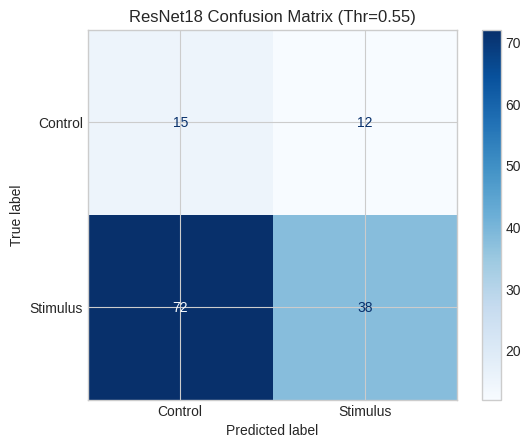

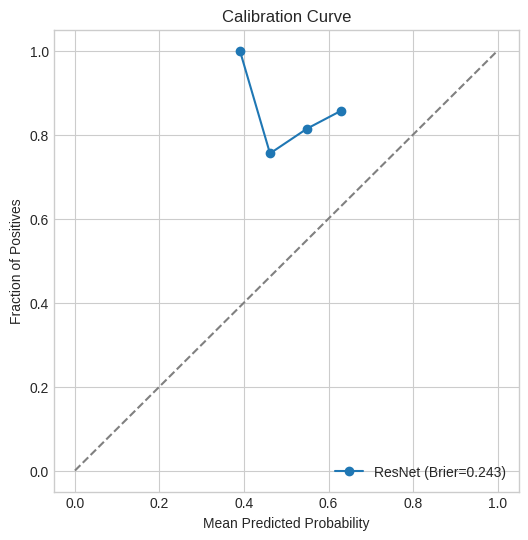


--- Per-Baby Balanced Accuracy and F1 Scores ---
------------------------------------------------------------
BabyID          | Age   | Sex | Balanced Acc | F1 Score
------------------------------------------------------------
bam1_005        | 5.42  | F   | 0.3125       | 0.2000
bam1_024        | 6.41  | F   | 0.3583       | 0.5600
bam1_008        | 6.70  | F   | 0.3667       | 0.5217
bam1_020        | 4.83  | F   | 0.4062       | 0.4348
bam1_026        | 6.54  | F   | 0.4062       | 0.4348
bam1_044        | 6.08  | M   | 0.5938       | 0.5833
bam1_018        | 4.96  | M   | 0.6875       | 0.5455
------------------------------------------------------------


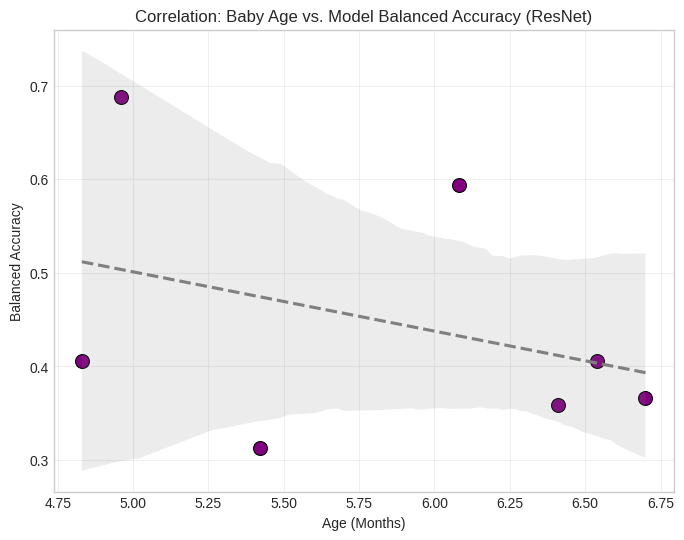

In [5]:
# ## 6. Final Evaluation (On Test)

# %%
print("📝 Running Final Evaluation on Test Set...")

test_probs = []
test_labels = []
metadata_list = [] # Store metadata for per-baby analysis

with torch.no_grad():
    for inputs, labels, meta in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        
        test_probs.extend(probs)
        test_labels.extend(labels.numpy())
        
        # Unpack metadata batch
        # DataLoader returns dict of lists, we want list of dicts
        batch_size_actual = len(labels)
        keys = meta.keys()
        for i in range(batch_size_actual):
            item = {k: meta[k][i] for k in keys}
            # Clean up tensors
            for k, v in item.items():
                if isinstance(v, torch.Tensor):
                    item[k] = v.item()
            metadata_list.append(item)

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# Apply Optimized Threshold
y_pred_test = (test_probs >= best_thr).astype(int)

# Metrics
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print("\n--- TEST SET RESULTS ---")
print(f"Balanced Accuracy: {bal_test:.4f}")
print(f"MCC: {mcc_test:.4f}")
print(f"Brier Score: {brier_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"ResNet18 Confusion Matrix (Thr={best_thr:.2f})")
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"))
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label=f'ResNet (Brier={brier_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.savefig(os.path.join(RESULT_DIR, "calibration_curve.png"))
plt.show()

# %% [markdown]
# ## 7. Per-Baby Analysis & Age Correlation

# %%
# Reconstruct DataFrame
results_df = pd.DataFrame(metadata_list)
results_df['pred_label'] = y_pred_test
results_df['true_label'] = test_labels

# Aggregate by Patient
pt_ids = results_df['pt_id'].unique()
per_baby_details = []

for pid in pt_ids:
    sub = results_df[results_df['pt_id'] == pid]
    if len(sub) < 1: continue
    
    # Calculate F1 and balanced accuracy for this baby
    # Note: If baby has mixed labels (rare here), this works. 
    # If baby is pure Control/Stimulus, F1 is 1.0 or 0.0.
    f1 = f1_score(sub['true_label'].astype(int), sub['pred_label'], zero_division=0)
    bal_acc = balanced_accuracy_score(sub['true_label'].astype(int), sub['pred_label'])
    
    age = sub['age'].iloc[0]
    sex = sub['sex'].iloc[0]
    sex_str = "F" if str(sex) == "0" else "M"
    
    per_baby_details.append((pid, age, sex_str, bal_acc, f1))

# Sort by balanced accuracy Score
per_baby_details.sort(key=lambda x: x[3])

print("\n--- Per-Baby Balanced Accuracy and F1 Scores ---")
print("-" * 60)
print(f"{'BabyID':<15} | {'Age':<5} | {'Sex':<3} | {'Balanced Acc':<12} | {'F1 Score'}")
print("-" * 60)
for pid, age, sex, bal_acc, f1 in per_baby_details:
    print(f"{pid:<15} | {age:<5.2f} | {sex:<3} | {bal_acc:<12.4f} | {f1:.4f}")
print("-" * 60)

# Scatter Plot
ages = [x[1] for x in per_baby_details]
bal_accs = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=bal_accs, s=100, color='purple', edgecolor='black')
sns.regplot(x=ages, y=bal_accs, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model Balanced Accuracy (ResNet)")
plt.xlabel("Age (Months)")
plt.ylabel("Balanced Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULT_DIR, "age_correlation.png"))
plt.show()

## Bootstrap

>>> Step 5: Bootstrap Analysis on Test Set (ResNet18)
Generating predictions for ResNet18_GASF on full test set...
Starting bootstrap (n=200) for ResNet18_GASF (Augmented: No)...
  Bootstrap iteration 20/200...
  Bootstrap iteration 40/200...
  Bootstrap iteration 60/200...
  Bootstrap iteration 80/200...
  Bootstrap iteration 100/200...
  Bootstrap iteration 120/200...
  Bootstrap iteration 140/200...
  Bootstrap iteration 160/200...
  Bootstrap iteration 180/200...
  Bootstrap iteration 200/200...
Bootstrap runs used: 200/200
Balanced Acc: mean=0.4480, 95% CI=(0.3202, 0.5616)
F1 Score:     mean=0.4734, 95% CI=(0.3528, 0.5953)
AUC:          mean=0.4800, 95% CI=(0.3422, 0.6284)
Specificity:  mean=0.5497, 95% CI=(0.3122, 0.7500)
Appending new result.
Comparison results saved to /home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv


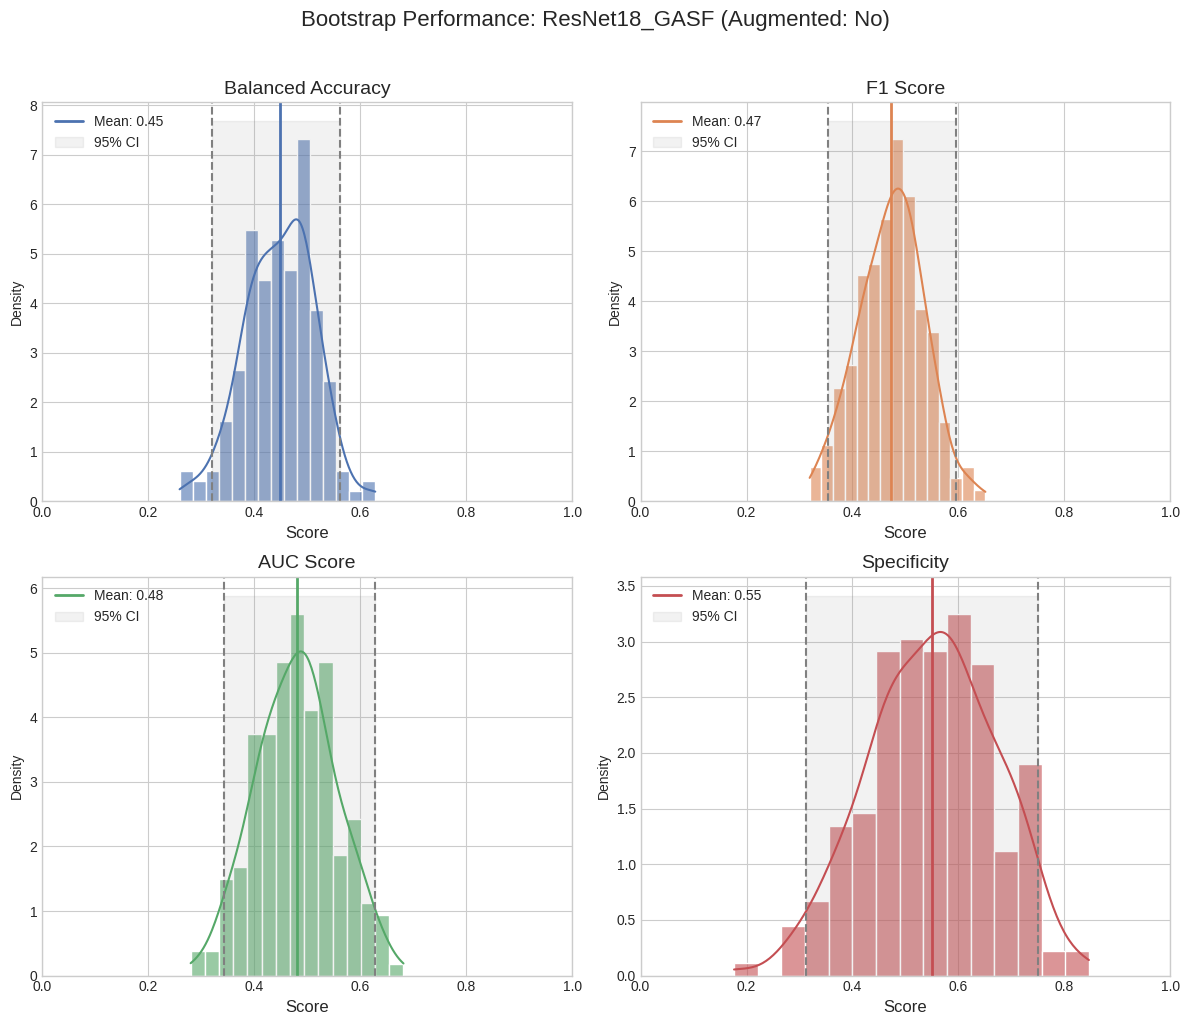

In [6]:
# %% --- 5. Bootstrap Analysis ---
print(">>> Step 5: Bootstrap Analysis on Test Set (ResNet18)")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
MODEL_NAME = "ResNet18_GASF"
# Determine augmentation status from DATASET_TYPE defined in your script
IS_AUGMENTED = "Yes" if "augmented" in DATASET_TYPE else "No"

# Path to the main comparison CSV (adjust path if necessary)
RESULTS_CSV_PATH = Path("/home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv")

# Use the RESULT_DIR already defined in your ResNet script
OUTPUT_DIR = Path(RESULT_DIR)

# Parameters
n_boot = 200
frac = 0.70
# Get total size from the test set wrapper or loader
N_test = len(dataloaders['test'].dataset) 
boot_size = max(1, int(round(frac * N_test)))

# --- PRE-CALCULATE PREDICTIONS ---
# We run inference once on the full test set to avoid re-running the NN 200 times.
# Assumes 'model' and 'best_thr' exist from previous steps in the notebook.

if 'best_thr' not in locals():
    print("Warning: 'best_thr' not found. Defaulting to 0.5")
    best_thr = 0.5

print(f"Generating predictions for {MODEL_NAME} on full test set...")
model.eval()
y_probs_all = []
y_true_all = []

with torch.no_grad():
    # Iterate over the test dataloader
    # ResNet loader returns: inputs (images), labels, meta (dict)
    for inputs, labels, _ in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        
        # Forward pass (Image only)
        outputs = model(inputs)
        
        # Apply Sigmoid to get probabilities
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        
        y_probs_all.extend(probs)
        y_true_all.extend(labels.numpy().flatten())

y_probs_all = np.array(y_probs_all)
y_true_all = np.array(y_true_all)

# --- BOOTSTRAP LOOP ---
rng = np.random.default_rng(42)
boot_bal_acc = []
boot_f1 = []
boot_auc = []
boot_specificity = []

print(f"Starting bootstrap (n={n_boot}) for {MODEL_NAME} (Augmented: {IS_AUGMENTED})...")

for i in range(n_boot):
    # Progress update every n_boot/10 iterations
    if (i+1) % (n_boot // 10) == 0:
        print(f"  Bootstrap iteration {i+1}/{n_boot}...")

    # Bootstrap indices
    idx = rng.choice(N_test, size=boot_size, replace=True)
    
    # Resample from pre-calculated predictions and labels
    pb = y_probs_all[idx]
    yb = y_true_all[idx]

    # Guard: need at least 2 classes for ROC AUC usually
    if len(np.unique(yb)) < 2:
        continue

    # Calculate Metrics
    try:
        yhat = (pb >= best_thr).astype(int)
        
        # Metrics
        boot_bal_acc.append(balanced_accuracy_score(yb, yhat))
        boot_f1.append(f1_score(yb, yhat, zero_division=0))
        boot_auc.append(roc_auc_score(yb, pb))
        
        # Specificity Calculation
        cm = confusion_matrix(yb, yhat)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            spec = np.nan 
        
        if not np.isnan(spec):
            boot_specificity.append(spec)
            
    except ValueError:
        continue

boot_res = pd.DataFrame({
    "balanced_accuracy": boot_bal_acc, 
    "f1": boot_f1, 
    "auc": boot_auc,
    "spec": boot_specificity
})

# Save Bootstrap raw results
os.makedirs(OUTPUT_DIR, exist_ok=True)
boot_res.to_csv(os.path.join(OUTPUT_DIR, "bootstrap_test_metrics.csv"), index=False)

# --- CI Calculation ---
def _ci(x, alpha=0.05):
    x = np.array(x)
    x = x[~np.isnan(x)]
    if len(x) == 0: return np.nan, np.nan
    lo, hi = np.percentile(x, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

bal_mean = boot_res["balanced_accuracy"].mean()
bal_ci = _ci(boot_res["balanced_accuracy"])

f1_mean = boot_res["f1"].mean()
f1_ci = _ci(boot_res["f1"])

auc_mean = boot_res["auc"].mean()
auc_ci = _ci(boot_res["auc"])

spec_mean = boot_res["spec"].mean()
spec_ci = _ci(boot_res["spec"])

print(f"Bootstrap runs used: {len(boot_res)}/{n_boot}")
print(f"Balanced Acc: mean={bal_mean:.4f}, 95% CI=({bal_ci[0]:.4f}, {bal_ci[1]:.4f})")
print(f"F1 Score:     mean={f1_mean:.4f}, 95% CI=({f1_ci[0]:.4f}, {f1_ci[1]:.4f})")
print(f"AUC:          mean={auc_mean:.4f}, 95% CI=({auc_ci[0]:.4f}, {auc_ci[1]:.4f})")
print(f"Specificity:  mean={spec_mean:.4f}, 95% CI=({spec_ci[0]:.4f}, {spec_ci[1]:.4f})")

# --- SAVE TO COMPARISON CSV ---
new_row = {
    "model": MODEL_NAME,
    "augmented": IS_AUGMENTED,
    "bal_acc_mean": round(bal_mean, 4),
    "bal_acc_ci_low": round(bal_ci[0], 4),
    "bal_acc_ci_high": round(bal_ci[1], 4),
    "auc_mean": round(auc_mean, 4),
    "auc_ci_low": round(auc_ci[0], 4),
    "auc_ci_high": round(auc_ci[1], 4),
    "f1_mean": round(f1_mean, 4),
    "f1_ci_low": round(f1_ci[0], 4),
    "f1_ci_high": round(f1_ci[1], 4),
    "spec_mean": round(spec_mean, 4),
    "spec_ci_low": round(spec_ci[0], 4),
    "spec_ci_high": round(spec_ci[1], 4)
}

RESULTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_CSV_PATH.exists():
    df_results = pd.read_csv(RESULTS_CSV_PATH)
    if "spec_mean" not in df_results.columns:
        df_results["spec_mean"] = np.nan
        df_results["spec_ci_low"] = np.nan
        df_results["spec_ci_high"] = np.nan
        
    mask = (df_results["model"] == MODEL_NAME) & (df_results["augmented"] == IS_AUGMENTED)
    if mask.any():
        print(f"Entry for {MODEL_NAME} (Augmented: {IS_AUGMENTED}) exists. Updating row.")
        for col, val in new_row.items():
            df_results.loc[mask, col] = val
    else:
        print(f"Appending new result.")
        df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)
else:
    print(f"Creating new results file.")
    df_results = pd.DataFrame([new_row])

df_results.to_csv(RESULTS_CSV_PATH, index=False)
print(f"Comparison results saved to {RESULTS_CSV_PATH}")

# --- PLOTTING ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
metrics_list = [
    ("balanced_accuracy", "Balanced Accuracy", bal_mean, bal_ci, colors[0]),
    ("f1", "F1 Score", f1_mean, f1_ci, colors[1]),
    ("auc", "AUC Score", auc_mean, auc_ci, colors[2]),
    ("spec", "Specificity", spec_mean, spec_ci, colors[3])
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle(f"Bootstrap Performance: {MODEL_NAME} (Augmented: {IS_AUGMENTED})", fontsize=16, y=1.02)

for ax, (col, title, mean_val, ci_val, color) in zip(axes, metrics_list):
    data = boot_res[col].dropna()
    sns.histplot(data, bins=15, kde=True, ax=ax, color=color, edgecolor='white', alpha=0.6, stat="density")
    ax.axvline(mean_val, color=color, linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(ci_val[0], color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(ci_val[1], color='gray', linestyle='--', linewidth=1.5)
    ymin, ymax = ax.get_ylim()
    ax.fill_betweenx([ymin, ymax], ci_val[0], ci_val[1], color='gray', alpha=0.1, label='95% CI')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bootstrap_test_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

## UMAP Visualization

🔄 Loading best model from: /home/phd2/Scrivania/CorsoRepo/Bambino/_03_train/resnet_on_images/resnet_dataset_augmented_normalized/results_resnet_augmented_normalized
⏳ Extracting embeddings from Test Set...


Extracting:   0%|          | 0/5 [00:00<?, ?it/s]

   ✅ Extracted 137 samples. Shape: (137, 32)
🌍 Running UMAP...
🎨 Generating Plot...


/home/phd2/Scrivania/CorsoVenvs/BambinoVenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/phd2/Scrivania/CorsoVenvs/BambinoVenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Aesthetic UMAP saved to: /home/phd2/Scrivania/CorsoRepo/Bambino/_03_train/resnet_on_images/resnet_dataset_augmented_normalized/results_resnet_augmented_normalized/resnet_umap_test_aesthetic.png


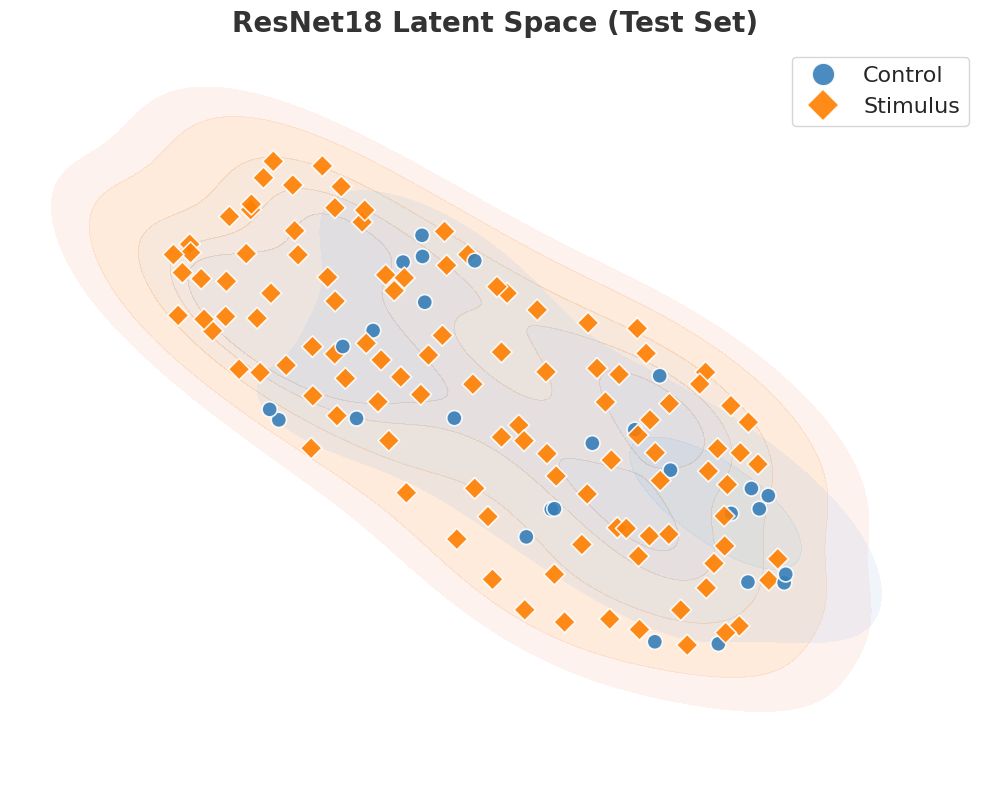

In [8]:
# %% --- ResNet Aesthetic UMAP Analysis ---
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
from pathlib import Path

# --- 1. Configuration & Styling ---
# Colorblind-Safe Palette (Blue vs Orange)
CB_PALETTE = {'Control': "#377eb8", 'Stimulus': "#ff7f00"}
MARKERS = {'Control': 'o', 'Stimulus': 'D'} 

SPECIFIC_RESULT_DIR = True
if SPECIFIC_RESULT_DIR:
    # Update this path if needed
    RESULT_DIR = "/home/phd2/Scrivania/CorsoRepo/Bambino/_03_train/resnet_on_images/resnet_dataset_augmented_normalized/results_resnet_augmented_normalized"
else:
    if 'RESULT_DIR' not in locals() or RESULT_DIR is None:
        raise ValueError("RESULT_DIR is not defined. Set it manually.")

OUTPUT_FILE = os.path.join(RESULT_DIR, "resnet_umap_test_aesthetic.png")

# --- 2. Load Model & Extract Embeddings ---
print(f"🔄 Loading best model from: {RESULT_DIR}")
best_model_path = os.path.join(RESULT_DIR, "best_resnet_model.pth")

# Re-initialize architecture
model = initialize_model().to(DEVICE)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Define Feature Extractor (Backbone + Partial Head -> 32-dim)
backbone = nn.Sequential(*list(model.children())[:-1])
partial_head = nn.Sequential(*list(model.fc.children())[:3]) # Up to ReLU

feature_extractor = nn.Sequential(
    backbone,
    nn.Flatten(),
    partial_head
)

print("⏳ Extracting embeddings from Test Set...")
embeddings = []
labels = []

with torch.no_grad():
    for inputs, targets, _ in tqdm(dataloaders['test'], desc="Extracting"):
        inputs = inputs.to(DEVICE)
        feats = feature_extractor(inputs)
        embeddings.append(feats.cpu().numpy())
        labels.append(targets.numpy())

X_emb = np.concatenate(embeddings, axis=0)
y_true = np.concatenate(labels, axis=0)

print(f"   ✅ Extracted {len(X_emb)} samples. Shape: {X_emb.shape}")

# --- 3. Compute UMAP ---
print("🌍 Running UMAP...")
reducer = umap.UMAP(
    n_neighbors=30,     # Increased for better global structure
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)
embedding_2d = reducer.fit_transform(X_emb)

# Prepare DataFrame for Seaborn
df_umap = pd.DataFrame(embedding_2d, columns=['x', 'y'])
df_umap['label'] = y_true
df_umap['Class'] = df_umap['label'].map({0: 'Control', 1: 'Stimulus'})

# --- 4. Plotting (Aesthetic Style) ---
print("🎨 Generating Plot...")
fig, ax = plt.subplots(figsize=(10, 8))

# A. Density Contours (The "Fancy" Part)
try:
    sns.kdeplot(
        data=df_umap, x='x', y='y', hue='Class',
        palette=CB_PALETTE, 
        fill=True, 
        alpha=0.15, 
        levels=6, 
        thresh=0.1, 
        legend=False, 
        ax=ax,
        cut=2
    )
except Exception as e:
    print(f"   ⚠️ KDE Plot failed ({e}), skipping contours.")

# B. Scatter Points
sns.scatterplot(
    data=df_umap, x='x', y='y', hue='Class',
    palette=CB_PALETTE,
    style='Class',
    markers=MARKERS,
    s=120,
    alpha=0.9,
    edgecolor='white',
    linewidth=1.2,
    ax=ax
)

# C. Clean Up (No Axes)
ax.axis('off')

# D. Custom Legend
handles, labels = ax.get_legend_handles_labels()
# Filter to ensure we don't duplicate (sometimes kde adds extra handles)
unique_labels = dict(zip(labels, handles))
ax.legend(
    handles=[unique_labels['Control'], unique_labels['Stimulus']], 
    labels=['Control', 'Stimulus'],
    title=None, 
    loc='upper right', 
    frameon=True, 
    fontsize=16,
    markerscale=1.5
)

# Title
plt.title("ResNet18 Latent Space (Test Set)", fontsize=20, fontweight='bold', color='#333333', pad=10)

# Save & Show
plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', transparent=False)
print(f"✅ Aesthetic UMAP saved to: {OUTPUT_FILE}")
plt.show()